**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD523 Inteligencia Artificial
**GRUPO:** GR1CC  
**FECHA DE ENTREGA LÍMITE:** 11/05/2026   
**ALUMNO:** Renato Aguilar

# Librerías usadas

In [7]:
import random
import matplotlib.pyplot as plt

# Código original

In [3]:
# Tamaño del tablero de ajedrez y número de reinas
n = 8
maxFitness = (n * (n - 1)) / 2  # 8*7/2 = 28

# Función de aptitud
def fitness(chromosome):
    horizontal_collisions = sum([chromosome.count(queen) - 1 for queen in chromosome]) / 2

    diagonal_collisions = sum([
        abs(chromosome[i] - chromosome[j]) == abs(i - j)
        for i in range(len(chromosome))
        for j in range(i + 1, len(chromosome))
    ])

    return int(maxFitness - (horizontal_collisions + diagonal_collisions))


# Función de cruce
def crossover(x, y):
    c = random.randint(0, n - 1)
    return x[0:c] + y[c:n]


# Función de mutación
def mutate(x):
    c = random.randint(0, n - 1)
    m = random.randint(1, n)
    x[c] = m
    return x


# Función de selección de padres para el cruce
def random_selection(population, probabilities):
    populationWithProbabilty = zip(population, probabilities)

    total = sum(w for c, w in populationWithProbabilty)
    r = random.uniform(0, total)
    upto = 0

    for c, w in zip(population, probabilities):
        if upto + w >= r:
            return c
        upto += w


# Algoritmo genético
def genetic_queen(population, fitness):
    mutation_probability = 0.03
    new_population = []

    probabilities = [fitness(n) for n in population]

    for i in range(len(population)):
        x = random_selection(population, probabilities)  # seleccionar padre 1
        y = random_selection(population, probabilities)  # seleccionar padre 2

        child = crossover(x, y)  # crear un hijo

        if random.random() < mutation_probability:
            child = mutate(child)

        new_population.append(child)

        if fitness(child) == maxFitness:
            break

    return new_population


# Generar la población inicial
population = [[random.randint(1, n) for _ in range(n)] for _ in range(100)]

for generation in range(100):
    print("Generation {} with {} members".format(generation, len(population)))

    population = genetic_queen(population, fitness)

    best_score = max([fitness(n) for n in population])

    print("Best score: ", best_score)

    if best_score == maxFitness:
        break


final_board = []

for x in population:
    if fitness(x) == maxFitness:
        print("One of the solutions: ")
        final_board = x
        print(final_board)


if final_board:  # Verificar que final_board no esté vacío
    board = []

    for x in range(n):
        board.append(["x"] * n)

    for i in range(n):
        board[n - final_board[i]][i] = "Q"


    def print_board(board):
        for row in board:
            print(" ".join(row))


    print_board(board)

else:
    print("No se encontró una solución después de 100 generaciones.")

Generation 0 with 100 members
Best score:  25
Generation 1 with 100 members
Best score:  25
Generation 2 with 100 members
Best score:  26
Generation 3 with 100 members
Best score:  25
Generation 4 with 100 members
Best score:  26
Generation 5 with 100 members
Best score:  26
Generation 6 with 100 members
Best score:  26
Generation 7 with 100 members
Best score:  25
Generation 8 with 100 members
Best score:  26
Generation 9 with 100 members
Best score:  25
Generation 10 with 100 members
Best score:  26
Generation 11 with 100 members
Best score:  25
Generation 12 with 100 members
Best score:  25
Generation 13 with 100 members
Best score:  25
Generation 14 with 100 members
Best score:  25
Generation 15 with 100 members
Best score:  25
Generation 16 with 100 members
Best score:  25
Generation 17 with 100 members
Best score:  25
Generation 18 with 100 members
Best score:  25
Generation 19 with 100 members
Best score:  25
Generation 20 with 100 members
Best score:  25
Generation 21 with 100 

# Código modificado

In [24]:
# Tamaño del tablero de ajedrez y número de reinas
n = 8
maxFitness = (n * (n - 1)) / 2  # 8*7/2 = 28

# Función de aptitud
def fitness(chromosome):
    # Cuenta reinas que se atacan en la misma fila
    horizontal_collisions = sum([chromosome.count(queen) - 1 for queen in chromosome]) / 2

    # Cuenta reinas que se atacan en diagonal
    diagonal_collisions = sum([
        abs(chromosome[i] - chromosome[j]) == abs(i - j)
        for i in range(len(chromosome))
        for j in range(i + 1, len(chromosome))
    ])

    # Mientras menos colisiones existan, mayor será la aptitud
    return int(maxFitness - (horizontal_collisions + diagonal_collisions))


# Cruce de un punto
def crossover_one_point(x, y):
    # Se escoge un punto de corte
    c = random.randint(0, n - 1)

    # El hijo toma una parte del primer padre y otra del segundo
    return x[0:c] + y[c:n]


# Cruce de dos puntos
def crossover_two_points(x, y):
    # Se escogen dos puntos de corte diferentes
    c1 = random.randint(0, n - 2)
    c2 = random.randint(c1 + 1, n - 1)

    # El hijo toma la parte central del segundo padre
    return x[0:c1] + y[c1:c2] + x[c2:n]


# Cruce uniforme
def crossover_uniform(x, y):
    child = []

    # Para cada posición se escoge al azar el gen de uno de los padres
    for i in range(n):
        if random.random() < 0.5:
            child.append(x[i])
        else:
            child.append(y[i])

    return child


# Función general de cruce
def crossover(x, y, tipo):
    if tipo == "un_punto":
        return crossover_one_point(x, y)
    elif tipo == "dos_puntos":
        return crossover_two_points(x, y)
    elif tipo == "uniforme":
        return crossover_uniform(x, y)
    else:
        return crossover_one_point(x, y)


# Función de mutación
def mutate(x):
    # Se cambia aleatoriamente una posición del cromosoma
    c = random.randint(0, n - 1)
    m = random.randint(1, n)

    x[c] = m

    return x


# Función de selección de padres para el cruce
def random_selection(population, probabilities):
    total = sum(probabilities)

    # Si todos tienen probabilidad cero, se elige un individuo al azar
    if total == 0:
        return random.choice(population)

    r = random.uniform(0, total)
    upto = 0

    for c, w in zip(population, probabilities):
        if upto + w >= r:
            return c
        upto += w


# Algoritmo genético
def genetic_queen(population, fitness, tipo_cruce):
    mutation_probability = 0.03
    new_population = []

    # Se calcula la aptitud de cada individuo
    probabilities = [fitness(chromosome) for chromosome in population]

    for i in range(len(population)):
        # Seleccionar padres
        x = random_selection(population, probabilities)
        y = random_selection(population, probabilities)

        # Crear hijo usando el tipo de cruce seleccionado
        child = crossover(x, y, tipo_cruce)

        # Aplicar mutación con cierta probabilidad
        if random.random() < mutation_probability:
            child = mutate(child)

        new_population.append(child)

        # Si se encontró una solución, se detiene la generación
        if fitness(child) == maxFitness:
            break

    return new_population


# Función para dibujar el tablero
def print_board(board):
    for row in board:
        print(" ".join(row))


# Función para construir el tablero con la solución encontrada
def draw_solution(final_board):
    board = []

    # Se crea el tablero vacío
    for x in range(n):
        board.append(["."] * n)

    # Se colocan las reinas en el tablero
    for i in range(n):
        board[n - final_board[i]][i] = "Q"

    print_board(board)

# Función para ver los resultados según el tipo de cruce
def solucion(tipo_cruce):
    # Generar la población inicial
    population = [[random.randint(1, n) for _ in range(n)] for _ in range(100)]

    
    # Listas para guardar el mejor valor de cada generación
    best_fitness_history = []
    best_cost_history = []
    
    for generation in range(100):
        print("Generation {} with {} members".format(generation, len(population)))
    
        population = genetic_queen(population, fitness, tipo_cruce)
    
        # Se obtiene la mejor aptitud de la generación
        best_score = max([fitness(chromosome) for chromosome in population])
    
        # El costo representa cuántas colisiones faltan por reducir
        cost = maxFitness - best_score
    
        # Se guardan los valores para graficar
        best_fitness_history.append(best_score)
        best_cost_history.append(cost)
    
        print("Best score: ", best_score)
        print("Cost: ", cost)
    
        if best_score == maxFitness:
            break
    
    
    # Buscar una solución dentro de la población final
    final_board = []
    
    for x in population:
        if fitness(x) == maxFitness:
            print("One of the solutions: ")
            final_board = x
            print(final_board)
            break
    
    
    # Mostrar la solución en forma de tablero
    if final_board:
        print("\nTablero solución:")
        draw_solution(final_board)
    else:
        print("No se encontró una solución después de 100 generaciones.")
    
    
    # Graficar el cambio de la aptitud y el costo
    plt.figure()
    plt.plot(best_fitness_history, label="Mejor aptitud")
    plt.plot(best_cost_history, label="Costo")
    plt.xlabel("Generación")
    plt.ylabel("Valor")
    plt.title("Evolución de la aptitud y el costo - Cruce: " + tipo_cruce)
    plt.legend()
    plt.grid(True)
    plt.show()

### Cruce de un punto

Generation 0 with 100 members
Best score:  25
Cost:  3.0
Generation 1 with 100 members
Best score:  25
Cost:  3.0
Generation 2 with 100 members
Best score:  25
Cost:  3.0
Generation 3 with 100 members
Best score:  24
Cost:  4.0
Generation 4 with 100 members
Best score:  26
Cost:  2.0
Generation 5 with 100 members
Best score:  26
Cost:  2.0
Generation 6 with 100 members
Best score:  25
Cost:  3.0
Generation 7 with 100 members
Best score:  24
Cost:  4.0
Generation 8 with 100 members
Best score:  25
Cost:  3.0
Generation 9 with 100 members
Best score:  25
Cost:  3.0
Generation 10 with 100 members
Best score:  25
Cost:  3.0
Generation 11 with 100 members
Best score:  25
Cost:  3.0
Generation 12 with 100 members
Best score:  25
Cost:  3.0
Generation 13 with 100 members
Best score:  25
Cost:  3.0
Generation 14 with 100 members
Best score:  26
Cost:  2.0
Generation 15 with 100 members
Best score:  25
Cost:  3.0
Generation 16 with 100 members
Best score:  25
Cost:  3.0
Generation 17 with 100 m

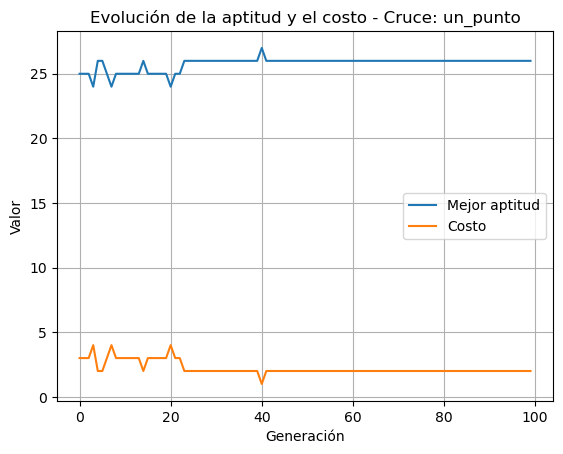

In [25]:
solucion('un_punto')

### Cruce de dos puntos

Generation 0 with 100 members
Best score:  26
Cost:  2.0
Generation 1 with 100 members
Best score:  25
Cost:  3.0
Generation 2 with 100 members
Best score:  26
Cost:  2.0
Generation 3 with 100 members
Best score:  25
Cost:  3.0
Generation 4 with 100 members
Best score:  26
Cost:  2.0
Generation 5 with 100 members
Best score:  26
Cost:  2.0
Generation 6 with 100 members
Best score:  26
Cost:  2.0
Generation 7 with 100 members
Best score:  25
Cost:  3.0
Generation 8 with 100 members
Best score:  25
Cost:  3.0
Generation 9 with 100 members
Best score:  25
Cost:  3.0
Generation 10 with 100 members
Best score:  26
Cost:  2.0
Generation 11 with 100 members
Best score:  25
Cost:  3.0
Generation 12 with 100 members
Best score:  25
Cost:  3.0
Generation 13 with 100 members
Best score:  26
Cost:  2.0
Generation 14 with 100 members
Best score:  25
Cost:  3.0
Generation 15 with 100 members
Best score:  26
Cost:  2.0
Generation 16 with 100 members
Best score:  25
Cost:  3.0
Generation 17 with 100 m

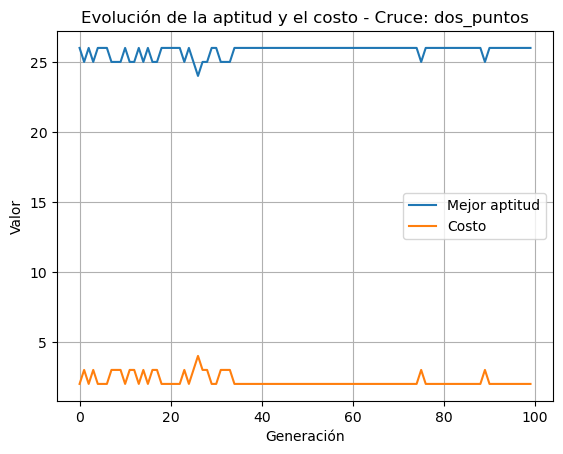

In [27]:
solucion('dos_puntos')

### Cruce uniforme

Generation 0 with 100 members
Best score:  25
Cost:  3.0
Generation 1 with 100 members
Best score:  25
Cost:  3.0
Generation 2 with 100 members
Best score:  26
Cost:  2.0
Generation 3 with 100 members
Best score:  26
Cost:  2.0
Generation 4 with 100 members
Best score:  25
Cost:  3.0
Generation 5 with 100 members
Best score:  25
Cost:  3.0
Generation 6 with 100 members
Best score:  26
Cost:  2.0
Generation 7 with 100 members
Best score:  26
Cost:  2.0
Generation 8 with 100 members
Best score:  25
Cost:  3.0
Generation 9 with 100 members
Best score:  25
Cost:  3.0
Generation 10 with 100 members
Best score:  26
Cost:  2.0
Generation 11 with 100 members
Best score:  24
Cost:  4.0
Generation 12 with 100 members
Best score:  26
Cost:  2.0
Generation 13 with 100 members
Best score:  26
Cost:  2.0
Generation 14 with 100 members
Best score:  26
Cost:  2.0
Generation 15 with 100 members
Best score:  26
Cost:  2.0
Generation 16 with 100 members
Best score:  26
Cost:  2.0
Generation 17 with 100 m

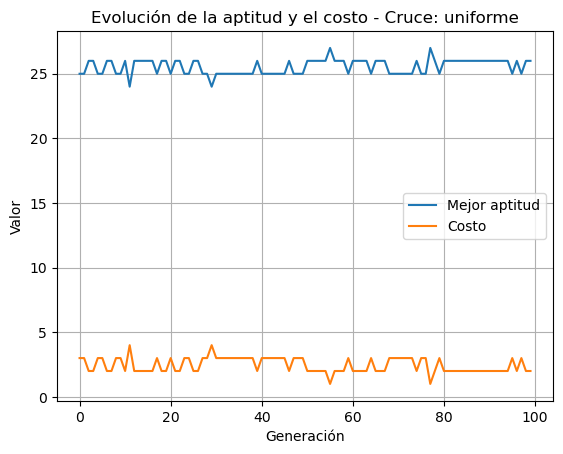

In [28]:
solucion('uniforme')